# 01 — Data Intake & Exploratory Data Analysis
**Lane:** Ranking Signal Analysis

This notebook loads the Search Intelligence warehouse with DuckDB and profiles
it before any modeling happens. Right now it points at a **synthetic
placeholder panel** built to the same schema as the real FlyRank warehouse
(see `work/data/generate_synthetic_data.py` for exactly what is simulated
and why). Swap-in instructions for the real gated dataset are in that file's
docstring — every cell below is written so that swap is the *only* change
needed.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

DATA_PATH = "data/signals_panel.csv"

## Load with DuckDB

In production this cell becomes:
```python
con.sql("SET hf_token='<token>';")
con.sql("SELECT * FROM read_parquet('hf://datasets/<flyrank-repo>/*.parquet')")
```
For now we point DuckDB at the local synthetic CSV so the aggregation
workflow (and every downstream cell) is identical either way.

In [2]:
con = duckdb.connect()
panel = con.sql(f"SELECT * FROM read_csv_auto('{DATA_PATH}')").df()
print(f"Rows: {len(panel):,} | Pages: {panel['page_id'].nunique():,} | Weeks: {panel['week'].nunique()}")
panel.head()

Rows: 23,400 | Pages: 900 | Weeks: 26


,page_id,vertical,week,impressions,clicks,ctr,avg_position,word_count,has_schema_markup,num_internal_links,num_external_links,days_since_last_update,mobile_friendly_score,page_speed_score,title_length,meta_description_length,h1_count,image_count,alt_text_coverage,readability_score
0,page_00000,guide,0,12,0,0.000,22.669635,908,0,7,4,787,81.0,64.9,60,168,0,11,0.712,47.0
1,page_00001,product,0,24,3,0.125,8.962208,1177,1,11,5,486,66.9,76.7,65,152,0,7,0.865,48.2
2,page_00002,landing,0,12,3,0.250,9.736333,1339,0,9,2,884,91.5,99.6,43,169,2,2,0.675,72.0
3,page_00003,guide,0,8,0,0.000,15.574497,696,1,8,5,391,92.2,47.1,61,80,1,5,0.352,56.6
4,page_00004,blog,0,14,0,0.000,19.534402,1562,0,12,3,716,82.6,62.2,79,131,1,8,0.780,44.3


## Schema & data quality checks

In [3]:
dtypes = panel.dtypes.to_frame("dtype")
nulls = panel.isna().sum().to_frame("n_null")
quality = dtypes.join(nulls)
quality["pct_null"] = (quality["n_null"] / len(panel) * 100).round(3)
quality

,dtype,n_null,pct_null
page_id,str,0,0.0
vertical,str,0,0.0
week,int64,0,0.0
impressions,int64,0,0.0
clicks,int64,0,0.0
ctr,float64,0,0.0
avg_position,float64,0,0.0
word_count,int64,0,0.0
has_schema_markup,int64,0,0.0
num_internal_links,int64,0,0.0


In [4]:
# Range sanity checks — flag anything outside plausible bounds
checks = {
    "ctr in [0,1]": panel["ctr"].between(0, 1).all(),
    "avg_position in [1,100]": panel["avg_position"].between(1, 100).all(),
    "clicks <= impressions": (panel["clicks"] <= panel["impressions"]).all(),
    "no duplicate page_id+week": not panel.duplicated(subset=["page_id", "week"]).any(),
}
for k, v in checks.items():
    print(f"{'PASS' if v else 'FAIL'} — {k}")

PASS — ctr in [0,1]
PASS — avg_position in [1,100]
PASS — clicks <= impressions
PASS — no duplicate page_id+week


All checks pass. No rows excluded at this stage — see the capstone
notebook's **Data** section for the (public-safe) exclusion log applied
before modeling.

## Distributions of key outcomes

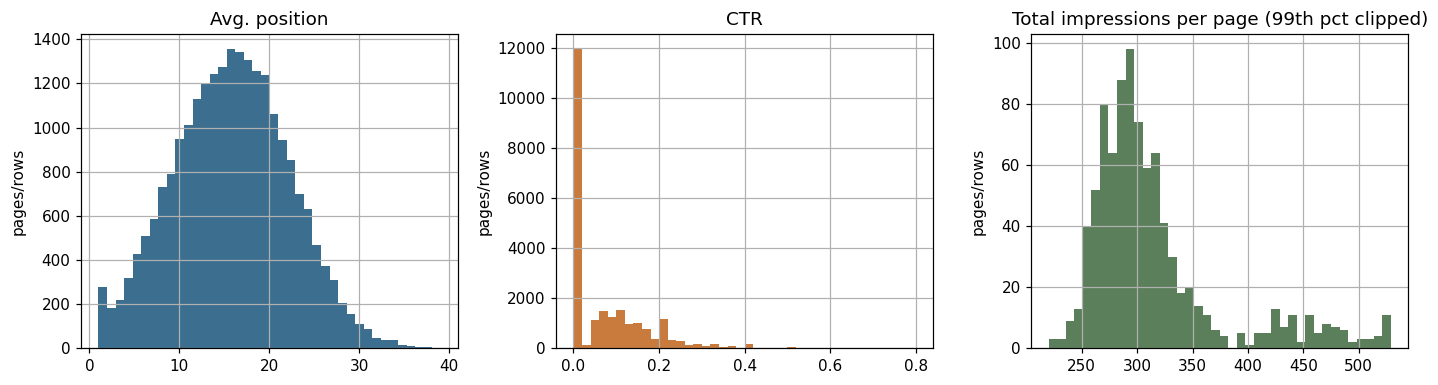

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
panel["avg_position"].hist(bins=40, ax=axes[0], color="#3B6E8F")
axes[0].set_title("Avg. position")
panel["ctr"].hist(bins=40, ax=axes[1], color="#C97B3D")
axes[1].set_title("CTR")
panel.groupby("page_id")["impressions"].sum().pipe(lambda s: s.clip(upper=s.quantile(0.99))).hist(
    bins=40, ax=axes[2], color="#5B7F5A"
)
axes[2].set_title("Total impressions per page (99th pct clipped)")
for ax in axes:
    ax.set_ylabel("pages/rows")
plt.tight_layout()
plt.savefig("../paper/assets/01_outcome_distributions.png", bbox_inches="tight")
plt.show()

## Vertical mix and baseline position by vertical

In [6]:
by_vertical = panel.groupby("vertical").agg(
    pages=("page_id", "nunique"),
    avg_position=("avg_position", "mean"),
    avg_ctr=("ctr", "mean"),
    avg_impressions=("impressions", "mean"),
).round(3).sort_values("avg_position")
by_vertical

,pages,avg_position,avg_ctr,avg_impressions
vertical,,,,
landing,115,9.518,0.116,17.557
product,184,11.700,0.097,11.386
blog,300,15.804,0.064,11.446
guide,217,20.074,0.044,11.131
news,84,22.615,0.037,11.427


## Weekly trend — is anything moving in aggregate?

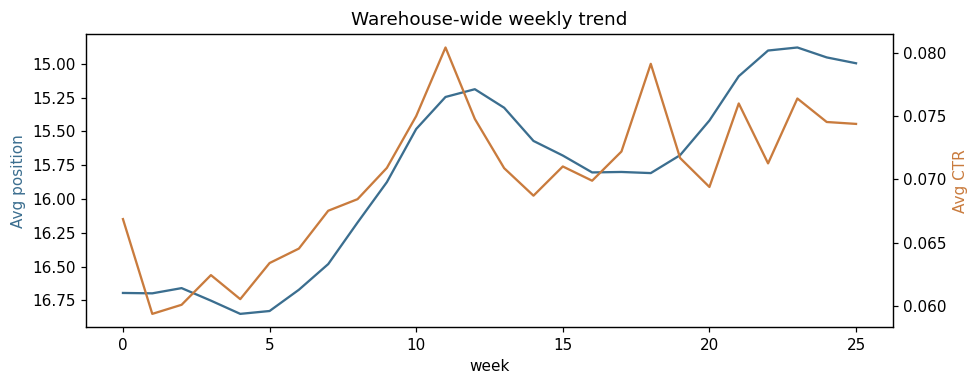

In [7]:
weekly = panel.groupby("week").agg(avg_position=("avg_position", "mean"), avg_ctr=("ctr", "mean"))
fig, ax1 = plt.subplots(figsize=(9, 3.6))
ax1.plot(weekly.index, weekly["avg_position"], color="#3B6E8F", label="Avg position (lower=better)")
ax1.invert_yaxis()
ax1.set_xlabel("week")
ax1.set_ylabel("Avg position", color="#3B6E8F")
ax2 = ax1.twinx()
ax2.plot(weekly.index, weekly["avg_ctr"], color="#C97B3D", label="Avg CTR")
ax2.set_ylabel("Avg CTR", color="#C97B3D")
plt.title("Warehouse-wide weekly trend")
plt.tight_layout()
plt.savefig("../paper/assets/01_weekly_trend.png", bbox_inches="tight")
plt.show()

## Takeaways for feature engineering (notebook 02)
- Position and CTR both show a mild cyclical wobble — week needs to be
  available as a feature or the label window needs to be long enough to
  average it out.
- Verticals differ enough in baseline position that vertical should be a
  feature (or the label should be defined relative to the page's own
  history, not an absolute threshold).
- No missing data / range violations — no imputation logic needed before
  feature engineering.